# 📈 Extracting and Visualizing Stock Data


## Project objectives

This notebook demonstrates a complete beginner data-science workflow:

- Extract historical stock prices with `yfinance`
- Scrape quarterly revenue from HTML pages with `requests` and `BeautifulSoup`
- Convert scraped HTML tables into Pandas DataFrames
- Clean financial values
- Visualize stock price and revenue



In [15]:


import warnings
from io import StringIO
from pathlib import Path

import requests
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("All libraries imported successfully.")


All libraries imported successfully.


In [16]:
def make_graph(stock_data, revenue_data, stock):
    # Match the time range used in the original project.
    stock_data_specific = stock_data[
        pd.to_datetime(stock_data["Date"]) <= "2021-06-14"
    ].copy()

    revenue_data_specific = revenue_data[
        pd.to_datetime(revenue_data["Date"]) <= "2021-04-30"
    ].copy()

    stock_dates = pd.to_datetime(stock_data_specific["Date"])
    revenue_dates = pd.to_datetime(revenue_data_specific["Date"])

    # Remove timezone information if yfinance supplied it.
    if getattr(stock_dates.dt, "tz", None) is not None:
        stock_dates = stock_dates.dt.tz_localize(None)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

    axes[0].plot(
        stock_dates,
        stock_data_specific["Close"].astype(float)
    )
    axes[0].set_title(f"{stock} Stock Price")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Share Price (USD)")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(
        revenue_dates,
        revenue_data_specific["Revenue"].astype(float)
    )
    axes[1].set_title(f"{stock} Quarterly Revenue")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Revenue (USD Millions)")
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# Using yfinance to Extract Tesla Stock Data

The Tesla ticker symbol is **TSLA**.

We create a ticker object and request the maximum available historical stock data.


In [17]:
tesla = yf.Ticker("TSLA")

tesla_data = tesla.history(
    period="max",
    auto_adjust=False
)

tesla_data.reset_index(inplace=True)

print("Tesla stock data shape:", tesla_data.shape)
tesla_data.head()


Tesla stock data shape: (4071, 9)


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,1.074000,103003500,0.0,0.0


# Using Web Scraping to Extract Tesla Revenue Data

The original lab supplies a static IBM Skills Network HTML page containing the Tesla revenue table.

We will:

1. Download the HTML using `requests`
2. Parse it with `BeautifulSoup`
3. Locate the revenue table
4. Convert it to a DataFrame
5. Clean the `Revenue` column


In [18]:
TESLA_REVENUE_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/"
    "labs/project/revenue.htm"
)

headers = {
    "User-Agent": "Mozilla/5.0 (compatible; StockDataLearningProject/1.0)"
}

response = requests.get(
    TESLA_REVENUE_URL,
    headers=headers,
    timeout=30
)

response.raise_for_status()

html_data = response.text

print("HTTP status:", response.status_code)
print("Downloaded HTML characters:", len(html_data))


HTTP status: 200
Downloaded HTML characters: 64779


In [19]:
# Parse the downloaded HTML with BeautifulSoup.

soup = BeautifulSoup(html_data, "html.parser")

html_tables = soup.find_all("table")

print("Number of HTML tables found:", len(html_tables))

# Show a short preview of each table so we can identify the revenue table.
for i, table in enumerate(html_tables):
    text = " ".join(table.stripped_strings)
    print(f"Table {i}: {text[:180]}")


Number of HTML tables found: 6
Table 0: Tesla Annual Revenue (Millions of US $) 2021 $53,823 2020 $31,536 2019 $24,578 2018 $21,461 2017 $11,759 2016 $7,000 2015 $4,046 2014 $3,198 2013 $2,013 2012 $413 2011 $204 2010 $1
Table 1: Tesla Quarterly Revenue (Millions of US $) 2022-09-30 $21,454 2022-06-30 $16,934 2022-03-31 $18,756 2021-12-31 $17,719 2021-09-30 $13,757 2021-06-30 $11,958 2021-03-31 $10,389 2020
Table 2: Sector Industry Market Cap Revenue Auto/Tires/Trucks Auto Manufacturers - Domestic $549.575B $53.823B Tesla is the market leader in battery-powered electric car sales in the United
Table 3: Stock Name Country Market Cap PE Ratio General Motors (GM) United States $53.930B 5.56 Ford Motor (F) United States $52.668B 8.09 Harley-Davidson (HOG) United States $6.762B 9.56 P
Table 4: Link Preview HTML Code (Click to Copy) Tesla Revenue 2010-2022 | TSLA Macrotrends Source
Table 5: Link Preview HTML Code (Click to Copy) Tesla Revenue 2010-2022 | TSLA Macrotrends Source


In [20]:
# Convert the HTML tables to Pandas DataFrames.
# The original lab identifies the quarterly revenue table as table index 1.
# We use a small amount of validation rather than blindly trusting the index.

tables = pd.read_html(StringIO(html_data))

tesla_revenue = None

for table in tables:
    table_text = " ".join(str(c) for c in table.columns)

    # Look for a two-column revenue table containing date-like values.
    if len(table.columns) >= 2:
        first_column = table.iloc[:, 0].astype(str)

        if (
            "revenue" in table_text.lower()
            and first_column.str.match(r"\d{4}-\d{2}-\d{2}").any()
        ):
            tesla_revenue = table.iloc[:, :2].copy()
            break

if tesla_revenue is None:
    # Fallback to the table index used in the original lab.
    tesla_revenue = tables[1].iloc[:, :2].copy()

tesla_revenue.columns = ["Date", "Revenue"]

tesla_revenue["Revenue"] = (
    tesla_revenue["Revenue"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

tesla_revenue["Date"] = pd.to_datetime(
    tesla_revenue["Date"],
    errors="coerce"
)

tesla_revenue = tesla_revenue[
    tesla_revenue["Date"].notna()
    & tesla_revenue["Revenue"].ne("")
    & tesla_revenue["Revenue"].notna()
].copy()

tesla_revenue["Revenue"] = pd.to_numeric(
    tesla_revenue["Revenue"],
    errors="coerce"
)

tesla_revenue.dropna(subset=["Revenue"], inplace=True)
tesla_revenue.reset_index(drop=True, inplace=True)

tesla_revenue.to_csv(
    OUTPUT_DIR / "tesla_revenue.csv",
    index=False
)

print("Tesla revenue data shape:", tesla_revenue.shape)
tesla_revenue.tail()


Tesla revenue data shape: (53, 2)


,Date,Revenue
48,2010-09-30,31.0
49,2010-06-30,28.0
50,2010-03-31,21.0
51,2009-09-30,46.0
52,2009-06-30,27.0


# Using yfinance to Extract GameStop Stock Data

The GameStop ticker symbol is **GME**.


In [21]:
gme = yf.Ticker("GME")

gme_data = gme.history(
    period="max",
    auto_adjust=False
)

gme_data.reset_index(inplace=True)

print("GameStop stock data shape:", gme_data.shape)
gme_data.head()


GameStop stock data shape: (6179, 9)


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,2.40625,2.51500,2.38125,2.51250,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,2.54375,2.54875,2.48125,2.50000,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,2.50000,2.50625,2.46250,2.48750,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,2.47500,2.47500,2.34375,2.38750,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,2.40000,2.46875,2.38125,2.46875,1.662210,6892800,0.0,0.0


# Using Web Scraping to Extract GameStop Revenue Data




In [22]:
GME_REVENUE_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/"
    "labs/project/stock.html"
)

response_gme = requests.get(
    GME_REVENUE_URL,
    headers=headers,
    timeout=30
)

response_gme.raise_for_status()

html_data_2 = response_gme.text

print("HTTP status:", response_gme.status_code)
print("Downloaded HTML characters:", len(html_data_2))


HTTP status: 200
Downloaded HTML characters: 88703


In [23]:
# Parse GameStop HTML with BeautifulSoup.

soup_gme = BeautifulSoup(html_data_2, "html.parser")

gme_html_tables = soup_gme.find_all("table")

print("Number of HTML tables found:", len(gme_html_tables))

for i, table in enumerate(gme_html_tables):
    text = " ".join(table.stripped_strings)
    print(f"Table {i}: {text[:180]}")


Number of HTML tables found: 6
Table 0: GameStop Annual Revenue (Millions of US $) 2020 $6,466 2019 $8,285 2018 $8,547 2017 $7,965 2016 $9,364 2015 $9,296 2014 $9,040 2013 $8,887 2012 $9,551 2011 $9,474 2010 $9,078 2009 
Table 1: GameStop Quarterly Revenue (Millions of US $) 2020-04-30 $1,021 2020-01-31 $2,194 2019-10-31 $1,439 2019-07-31 $1,286 2019-04-30 $1,548 2019-01-31 $3,063 2018-10-31 $1,935 2018-07-
Table 2: Sector Industry Market Cap Revenue Retail/Wholesale Retail - Consumer Electronics $0.293B $6.466B GameStop Corp. is the world's largest video game and entertainment software retail
Table 3: Stock Name Country Market Cap PE Ratio Best Buy (BBY) United States $27.033B 18.16 Aaron's,  (AAN) United States $3.975B 15.14 GOME Retail Holdings (GMELY) China $1.684B 0.00 Syste
Table 4: Link Preview HTML Code (Click to Copy) GameStop Revenue 2006-2020 | GME Macrotrends Source
Table 5: Link Preview HTML Code (Click to Copy) GameStop Revenue 2006-2020 | GME Macrotrends Source


In [24]:
tables_gme = pd.read_html(StringIO(html_data_2))

gme_revenue = None

for table in tables_gme:
    table_text = " ".join(str(c) for c in table.columns)

    if len(table.columns) >= 2:
        first_column = table.iloc[:, 0].astype(str)

        if (
            "revenue" in table_text.lower()
            and first_column.str.match(r"\d{4}-\d{2}-\d{2}").any()
        ):
            gme_revenue = table.iloc[:, :2].copy()
            break

if gme_revenue is None:
    gme_revenue = tables_gme[1].iloc[:, :2].copy()

gme_revenue.columns = ["Date", "Revenue"]

gme_revenue["Revenue"] = (
    gme_revenue["Revenue"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

gme_revenue["Date"] = pd.to_datetime(
    gme_revenue["Date"],
    errors="coerce"
)

gme_revenue = gme_revenue[
    gme_revenue["Date"].notna()
    & gme_revenue["Revenue"].ne("")
    & gme_revenue["Revenue"].notna()
].copy()

gme_revenue["Revenue"] = pd.to_numeric(
    gme_revenue["Revenue"],
    errors="coerce"
)

gme_revenue.dropna(subset=["Revenue"], inplace=True)
gme_revenue.reset_index(drop=True, inplace=True)

gme_revenue.to_csv(
    OUTPUT_DIR / "gme_revenue.csv",
    index=False
)

print("GameStop revenue data shape:", gme_revenue.shape)
gme_revenue.tail()


GameStop revenue data shape: (62, 2)


,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


# Ploting Tesla Stock Graph

Call the graphing function with:

```python
make_graph(tesla_data, tesla_revenue, "Tesla")
```


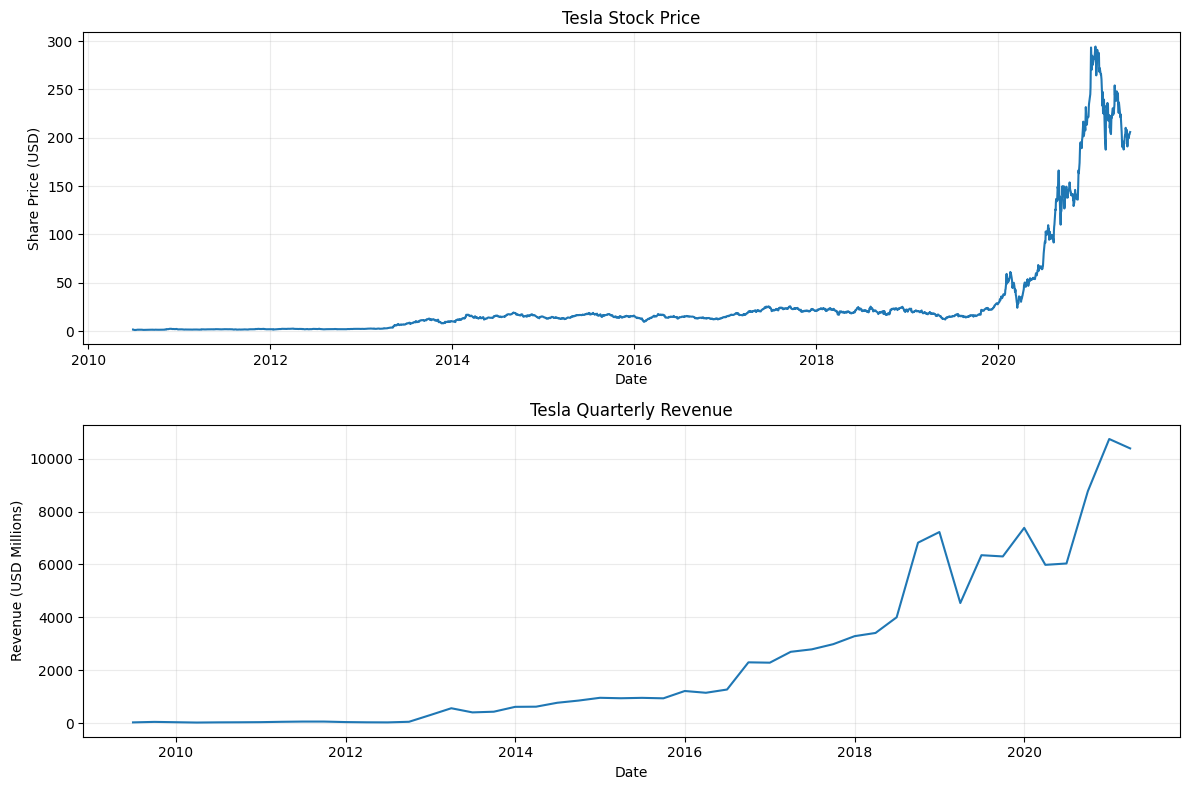

In [25]:
make_graph(
    tesla_data,
    tesla_revenue,
    "Tesla"
)


# Ploting GameStop Stock Graph

Call the graphing function with:

```python
make_graph(gme_data, gme_revenue, "GameStop")
```


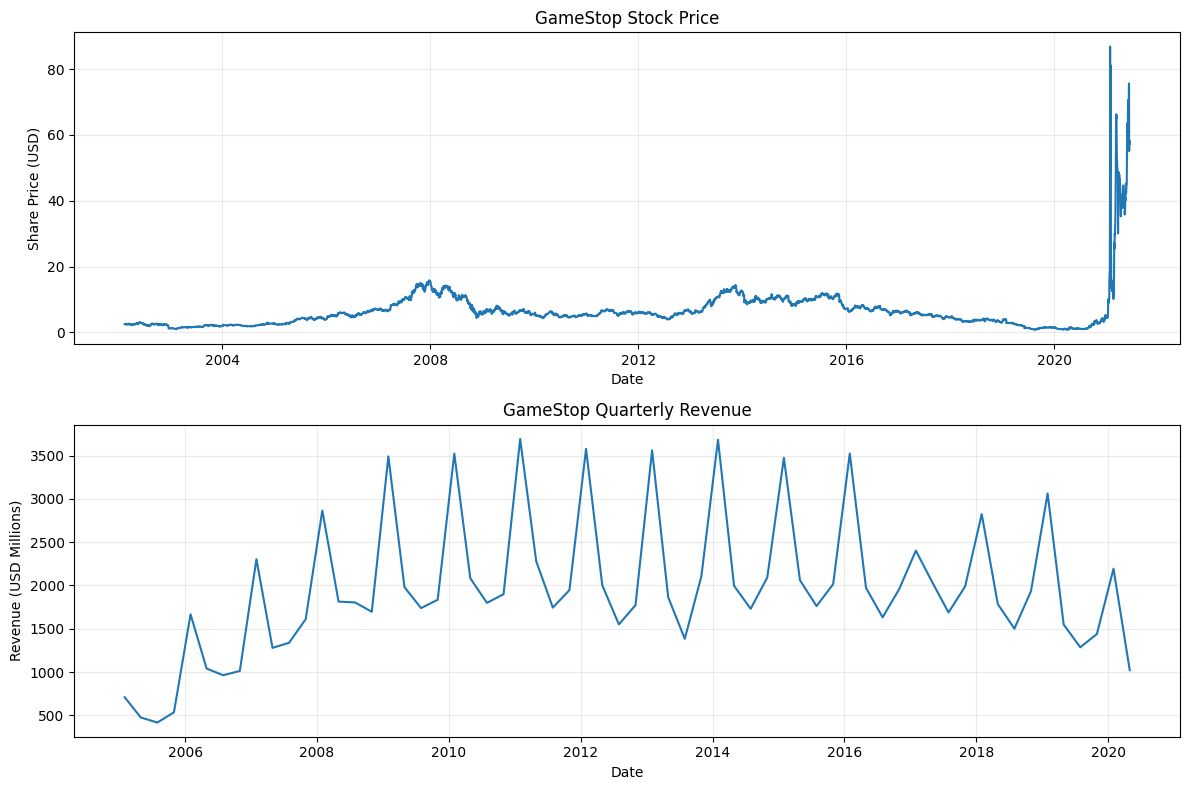

In [26]:
make_graph(
    gme_data,
    gme_revenue,
    "GameStop"
)


# Data Quality Check

Let's confirm that the scraped revenue datasets contain valid dates and numeric revenue values.


In [27]:
print("Tesla revenue:")
display(tesla_revenue.head())
print("\nTesla missing values:")
print(tesla_revenue.isna().sum())

print("\nGameStop revenue:")
display(gme_revenue.head())
print("\nGameStop missing values:")
print(gme_revenue.isna().sum())


Tesla revenue:


,Date,Revenue
0,2022-09-30,21454.0
1,2022-06-30,16934.0
2,2022-03-31,18756.0
3,2021-12-31,17719.0
4,2021-09-30,13757.0



Tesla missing values:
Date       0
Revenue    0
dtype: int64

GameStop revenue:


,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548



GameStop missing values:
Date       0
Revenue    0
dtype: int64
